In [74]:
# ==========================================================
# FINAL PROJECT V3
# TAHAP 1
# DATA PREPROCESSING
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

# ==========================================================
# CONFIGURATION
# ==========================================================

RANDOM_STATE = 42

TARGET = "PM2.5 (µg/m³)"

TIME_STEPS = 24

TEST_SIZE = 0.15

VAL_SIZE = 0.15

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("Air_Pollution_China.csv")

print("="*60)
print("DATASET")
print("="*60)

print(df.shape)


DATASET
(3000, 24)


In [75]:
# ==========================================================
# DATA CLEANING
# ==========================================================

df = df.drop_duplicates()

df = df.ffill()

df = df.dropna()

df.reset_index(drop=True, inplace=True)

print("Jumlah Data :", len(df))

# ==========================================================
# ORDINAL ENCODING
# ==========================================================

categorical_features = [

    "City",

    "Season",

    "Weather Condition"

]

encoder = OrdinalEncoder()

df[categorical_features] = encoder.fit_transform(
    df[categorical_features]
)

# joblib.dump(
#     encoder,
#     "ordinal_encoder.pkl"
# )

# joblib.dump(city, "model/city_encoder.pkl")

Jumlah Data : 3000


In [76]:
# ==========================================================
# CYCLIC ENCODING
# ==========================================================

day_map = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["Day of Week"] = df["Day of Week"].map(day_map)

# ==========================================================
# CYCLIC ENCODING
# ==========================================================

df["Hour_sin"] = np.sin(
    2*np.pi*df["Hour"]/24
)

df["Hour_cos"] = np.cos(
    2*np.pi*df["Hour"]/24
)

df["Month_sin"] = np.sin(
    2*np.pi*df["Month"]/12
)

df["Month_cos"] = np.cos(
    2*np.pi*df["Month"]/12
)

df["Day_sin"] = np.sin(
    2*np.pi*df["Day of Week"]/7
)

df["Day_cos"] = np.cos(
    2*np.pi*df["Day of Week"]/7
)

# ==========================================================
# DROP FEATURE
# ==========================================================

drop_columns = [

    "Station ID",

    "Hour",

    "Month",

    "Day of Week"

]

df.drop(columns=drop_columns,
        inplace=True)


# ==========================================================
# SPLIT FEATURE & TARGET
# ==========================================================

selected_features = [

    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "O3 (µg/m³)",

    "Temperature (°C)",
    "Humidity (%)",
    "Wind Speed (m/s)",
    "Pressure (hPa)",

    "Season",
    "City",
    "Weather Condition",

    "Hour_sin",
    "Hour_cos",

    "Month_sin",
    "Month_cos",

    "Day_sin",
    "Day_cos"

]

X = df[selected_features]

y = df[TARGET]

feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [77]:
# ==========================================================
# TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=(TEST_SIZE+VAL_SIZE),

    random_state=RANDOM_STATE,

    shuffle=False

)

val_ratio = VAL_SIZE/(TEST_SIZE+VAL_SIZE)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=1-val_ratio,

    random_state=RANDOM_STATE,
    
    shuffle=False

)

print("="*60)

print("TRAIN :",len(X_train))

print("VALID :",len(X_val))

print("TEST  :",len(X_test))

print("="*60)

# ==========================================================
# SCALING
# ==========================================================

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(X_train)

X_val = feature_scaler.transform(X_val)

X_test = feature_scaler.transform(X_test)

y_train = target_scaler.fit_transform(
    np.array(y_train).reshape(-1,1)
)

y_val = target_scaler.transform(
    np.array(y_val).reshape(-1,1)
)

y_test = target_scaler.transform(
    np.array(y_test).reshape(-1,1)
)

joblib.dump(
    feature_scaler,
    "feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    "target_scaler.pkl"
)


TRAIN : 2100
VALID : 450
TEST  : 450


['target_scaler.pkl']

In [78]:
cols = ["City", "Year", "Month", "Day of Week", "Hour"]
cols = [c for c in cols if c in df.columns]
print(df[cols].head(30))

    City  Year
0    4.0  2016
1    3.0  2017
2    0.0  2017
3    3.0  2020
4    0.0  2020
5    0.0  2024
6    4.0  2019
7    4.0  2023
8    1.0  2021
9    2.0  2017
10   3.0  2018
11   1.0  2021
12   0.0  2024
13   1.0  2022
14   3.0  2022
15   1.0  2015
16   2.0  2021
17   0.0  2024
18   1.0  2023
19   1.0  2018
20   1.0  2017
21   4.0  2022
22   3.0  2018
23   3.0  2018
24   1.0  2021
25   1.0  2020
26   3.0  2017
27   2.0  2017
28   0.0  2021
29   3.0  2016


In [79]:
print(df.columns.tolist())

['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)', 'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City', 'Latitude', 'Longitude', 'Year', 'Weather Condition', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']


In [80]:
# ==========================================================
# CREATE SEQUENCE
# ==========================================================

def create_sequence(
        X,
        y,
        time_steps):

    Xs=[]

    ys=[]

    for i in range(
        len(X)-time_steps
    ):

        Xs.append(
            X[i:(i+time_steps)]
        )

        ys.append(
            y[i+time_steps]
        )

    return (

        np.array(Xs),

        np.array(ys)

    )

X_train,y_train=create_sequence(

    X_train,

    y_train,

    TIME_STEPS

)

X_val,y_val=create_sequence(

    X_val,

    y_val,

    TIME_STEPS

)

X_test,y_test=create_sequence(

    X_test,

    y_test,

    TIME_STEPS

)

print("\nShape Dataset")

print("X_train :",X_train.shape)

print("X_val   :",X_val.shape)

print("X_test  :",X_test.shape)


Shape Dataset
X_train : (2076, 24, 18)
X_val   : (426, 24, 18)
X_test  : (426, 24, 18)


In [81]:
# ==========================================================
# TAHAP 2
# IMPROVED LSTM MODEL
# ==========================================================

import tensorflow as tf

from keras.models import Sequential

from keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from keras.optimizers import Adam

# ==========================================================
# RANDOM SEED
# ==========================================================

tf.keras.utils.set_random_seed(42)

# ==========================================================
# MODEL
# ==========================================================

model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    BatchNormalization(),

    Dropout(0.20),

    LSTM(
        64,
        return_sequences=False
    ),

    BatchNormalization(),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

# ==========================================================
# COMPILE
# ==========================================================

optimizer = Adam(
    learning_rate=0.001
)

model.compile(

    optimizer=optimizer,

    loss=tf.keras.losses.Huber(),

    metrics=["mae"]

)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 24, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,065 (500.25 KB)

 Trainable params: 127,681 (498.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [82]:
# ==========================================================
# CALLBACK
# ==========================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

callbacks = [

    early_stop,

    reduce_lr,

    checkpoint

]

# ==========================================================
# TRAINING
# ==========================================================

history = model.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1832 - mae: 0.4866
Epoch 1: val_loss improved from None to 0.11668, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 144ms/step - loss: 0.1342 - mae: 0.4144 - val_loss: 0.1167 - val_mae: 0.4060 - learning_rate: 0.0010
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.0762 - mae: 0.3173
Epoch 2: val_loss improved from 0.11668 to 0.10613, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step - loss: 0.0731 - mae: 0.3104 - val_loss: 0.1061 - val_mae: 0.3838 - learning_rate: 0.0010
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0660 - mae: 0.2969
Epoch 3: val_loss improved from 0.10613 to 0.07960, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - loss: 0.0642 - mae: 0.2931 - val_loss: 

In [83]:
# ==========================================================
# PREDICTION
# ==========================================================

y_pred = model.predict(X_test)

# Kembalikan ke skala asli
y_test_actual = target_scaler.inverse_transform(y_test)
y_pred_actual = target_scaler.inverse_transform(y_pred)

# ==========================================================
# EVALUATION
# ==========================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step
MODEL PERFORMANCE
RMSE : 69.29
MAE  : 57.46
R²   : -0.1277


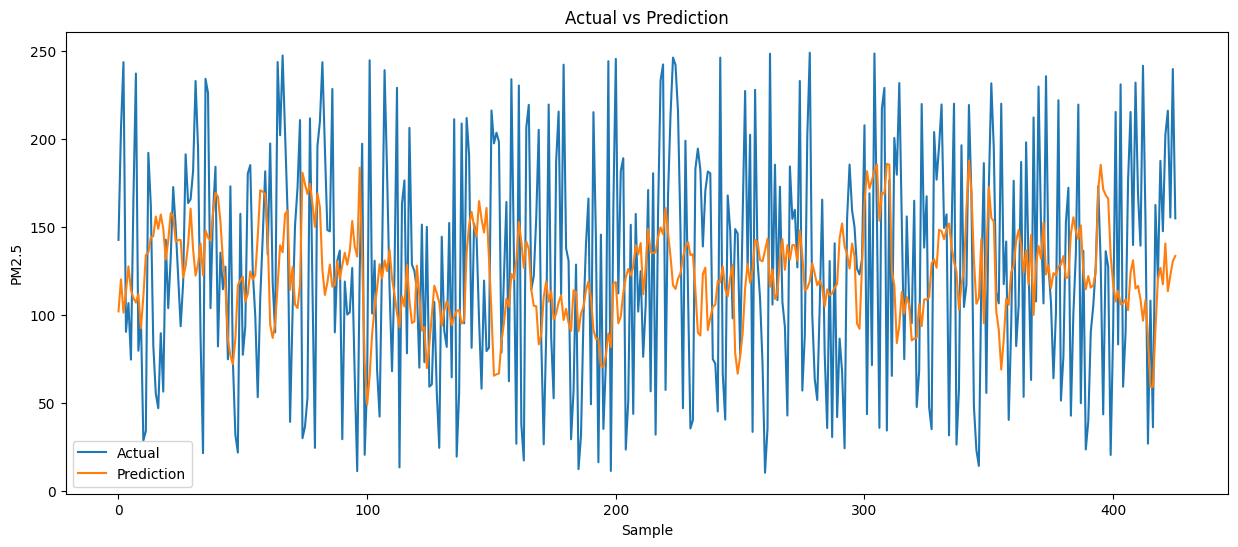

In [84]:
# ==========================================================
# ACTUAL vs PREDICTION
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    y_pred_actual,
    label="Prediction"
)

plt.title("Actual vs Prediction")

plt.xlabel("Sample")

plt.ylabel("PM2.5")

plt.legend()

plt.show()

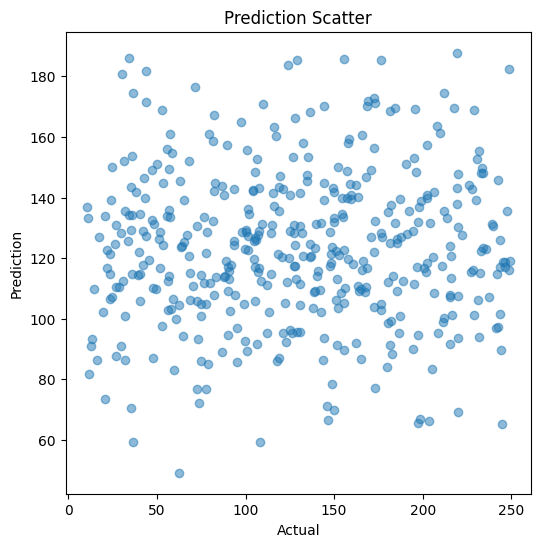

In [85]:
# ==========================================================
# SCATTER
# ==========================================================

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("Prediction Scatter")

plt.show()

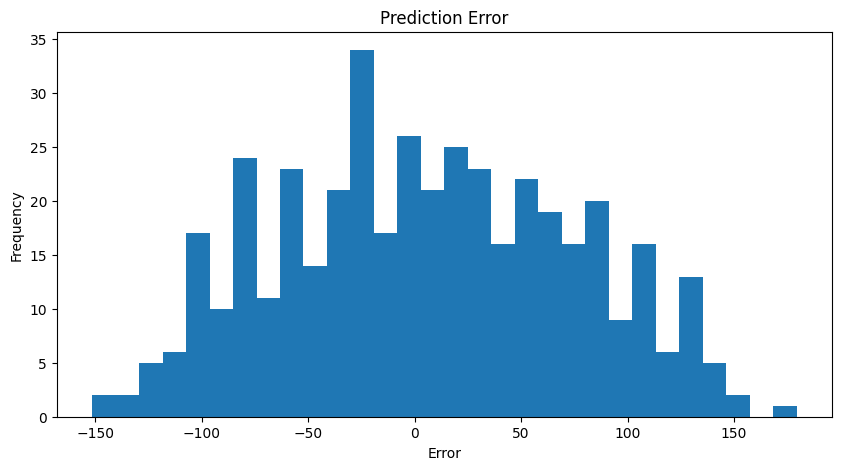

In [86]:
# ==========================================================
# ERROR DISTRIBUTION
# ==========================================================

error = y_test_actual.flatten() - y_pred_actual.flatten()

plt.figure(figsize=(10,5))

plt.hist(
    error,
    bins=30
)

plt.title("Prediction Error")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()